# Patchification Geometry Search

Evaluates 4 patch connectivity schemes on CIFAR-10 using two geometry metrics:
1. **PCA effective rank** (elbow@90% energy — lower = more structured)
2. **Approximate Tukey depth area** (higher = more concentrated, less shatterable)

**Schemes**:
- **Conv Patches**: standard sliding window 4×4, stride 2 (baseline)
- **Random Patches**: contiguous 4×4 crops at random spatial locations (local structure, irregular grid)
- **ShufflePixel**: globally shuffled pixels before patching (negative control — bad geometry)
- **Full Image Space**: flattened 3072-D image (computed inline in the final plot cell)

In [15]:
# =============================================================================
# Cell 0: Imports, seeds, device, plotting config
# =============================================================================
import os, math, gc, time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from tqdm.auto import tqdm

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

PLOT_CONFIG = {
    'title_fontsize'  : 16,
    'label_fontsize'  : 14,
    'tick_fontsize'   : 13,
    'legend_fontsize' : 13,
    'linewidth'       : 2.5,
    'double_fig_size' : (16, 6),
    'grid_alpha'      : 0.3,
    'dpi'             : 300,
}

plt.rcParams.update({
    'font.size'        : PLOT_CONFIG['tick_fontsize'],
    'axes.titlesize'   : PLOT_CONFIG['title_fontsize'],
    'axes.labelsize'   : PLOT_CONFIG['label_fontsize'],
    'xtick.labelsize'  : PLOT_CONFIG['tick_fontsize'],
    'ytick.labelsize'  : PLOT_CONFIG['tick_fontsize'],
    'legend.fontsize'  : PLOT_CONFIG['legend_fontsize'],
    'figure.dpi'       : PLOT_CONFIG['dpi'],
    'lines.linewidth'  : PLOT_CONFIG['linewidth'],
})

def decimal_tick_formatter(x, pos):
    if x == 0: return '0'
    elif abs(x) >= 1: return f'{x:.1f}'
    elif abs(x) >= 0.1: return f'{x:.2f}'
    elif abs(x) >= 0.01: return f'{x:.3f}'
    else: return f'{x:.4f}'

fmt = FuncFormatter(decimal_tick_formatter)
print("Config loaded.")

Device: cuda
Config loaded.


In [16]:
# =============================================================================
# Cell 1: Load CIFAR-10, build flat image tensor on GPU
# =============================================================================
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DATA_ROOT  = "./data"
BATCH_SIZE = 256
NUM_WORKERS = 2

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

dataset = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"), drop_last=False)

N_IMAGES = len(dataset)   # 50 000
H = W = 32
C = 3
D_IMG = C * H * W         # 3072

# Load all images flat: [50000, 3072]
X_all = torch.empty((N_IMAGES, D_IMG), device=DEVICE, dtype=torch.float32)
cur = 0
with torch.no_grad():
    for imgs, _ in tqdm(loader, desc="Loading images"):
        b = imgs.shape[0]
        X_all[cur:cur+b] = imgs.to(DEVICE, non_blocking=True).reshape(b, -1)
        cur += b

print(f"X_all: {tuple(X_all.shape)}, dtype={X_all.dtype}, device={X_all.device}")

Loading images: 100%|██████████| 196/196 [00:04<00:00, 44.39it/s]

X_all: (50000, 3072), dtype=torch.float32, device=cuda:0


In [17]:
# =============================================================================
# Cell 2: Patchification schemes
# Each scheme returns a pixel-index tensor of shape [L, K] where
#   L = number of output positions,
#   K = pixels per patch (receptive field size).
# Pixel indices are into a flattened CHW image (C*H*W = 3072).
# =============================================================================

PATCH_SIZE = 4    # 4×4 spatial extent for all schemes
STRIDE     = 2    # for conv

def _chw_idx(c, y, x, H=32, W=32):
    return c * H * W + y * W + x

def _patch_indices_for_position(top_y, left_x, patch_h, patch_w, H=32, W=32, C=3):
    idx = []
    for c in range(C):
        for dy in range(patch_h):
            for dx in range(patch_w):
                y = min(max(top_y + dy, 0), H-1)
                x = min(max(left_x + dx, 0), W-1)
                idx.append(_chw_idx(c, y, x))
    return idx

# ---------------------------------------------------------------------------
# Conv: standard sliding window 4×4, stride 2 — BASELINE
# ---------------------------------------------------------------------------
def scheme_conv(patch_size=4, stride=2, H=32, W=32, C=3):
    out_h = (H - patch_size) // stride + 1
    out_w = (W - patch_size) // stride + 1
    indices = []
    for oy in range(out_h):
        for ox in range(out_w):
            indices.append(_patch_indices_for_position(
                oy * stride, ox * stride, patch_size, patch_size, H, W, C))
    return torch.tensor(indices, dtype=torch.long)

# ---------------------------------------------------------------------------
# ShufflePixel: globally permuted pixels before conv-style patching
# (negative control — destroys all local spatial structure)
# ---------------------------------------------------------------------------
def scheme_shufflepixel(patch_size=4, stride=2, H=32, W=32, C=3, seed=99):
    base = scheme_conv(patch_size, stride, H, W, C)
    rng  = torch.Generator()
    rng.manual_seed(seed)
    perm = torch.randperm(C * H * W, generator=rng)
    return perm[base]

SCHEMES = {
    "Conv"         : scheme_conv(),
    "ShufflePixel" : scheme_shufflepixel(),
}

for name, idx in SCHEMES.items():
    print(f"{name:15s}: L={idx.shape[0]:4d} positions, K={idx.shape[1]:3d} pixels/patch")

In [19]:

# =============================================================================
# Cell 2c: Random Patches (RandomPlacement)
# Each of L positions gets an independently chosen random top-left corner and
# takes the contiguous 4×4 crop from that location.  Same patch *content*
# statistics as Conv (contiguous 4×4 RGB), but positions are scattered
# randomly across the image rather than on a regular grid.
#
# Hypothesis: if patch content (local contiguity) is what drives good geometry,
# RandomPlacement should score close to Conv.  If regular-grid structure
# matters, it will score lower.
# =============================================================================

def scheme_random_placement(patch_size=4, L=225, H=32, W=32, C=3, seed=13):
    """
    L positions, each with a randomly chosen (top_y, left_x) sampled uniformly
    from all valid top-left corners.  Fixed at construction time.
    """
    rng = np.random.default_rng(seed)
    indices = []
    for _ in range(L):
        top_y  = int(rng.integers(0, H - patch_size + 1))
        left_x = int(rng.integers(0, W - patch_size + 1))
        indices.append(_patch_indices_for_position(top_y, left_x, patch_size, patch_size, H, W, C))
    return torch.tensor(indices, dtype=torch.long)

SCHEMES["RandomPlacement"] = scheme_random_placement()

idx = SCHEMES["RandomPlacement"]
print(f"RandomPlacement: L={idx.shape[0]} positions, K={idx.shape[1]} pixels/patch")
print("(contiguous 4×4 RGB crops at random locations — same content as Conv, irregular grid)")


RandomPlacement: L=225 positions, K=48 pixels/patch
(contiguous 4×4 RGB crops at random locations — same content as Conv, irregular grid)


In [21]:

# =============================================================================
# Cell 4: Extract patches for each scheme
# Returns [N_REF, K] on GPU for geometry evaluation.
# =============================================================================

PATCH_REF_N   = 2_000_000
PATCH_QUERY_N = 50_000

def extract_patches(X_flat, idx_tensor, n_ref, n_query, seed=0, device=DEVICE):
    """
    X_flat:     [N_images, D_img] float32 on device
    idx_tensor: [L, K] long — pixel indices per output position
    Returns (REF [n_ref, K], QUERY [n_query, K]) both on device.
    """
    N, D = X_flat.shape
    L, K = idx_tensor.shape
    idx_gpu = idx_tensor.to(device)

    # Need enough draws to cover BOTH ref and query
    draws_per_img = max(1, math.ceil((n_ref + n_query) / N))
    draws_per_img = min(draws_per_img, L)
    actual_total  = N * draws_per_img

    assert actual_total >= n_ref + n_query, (
        f"Not enough patches: {actual_total} < {n_ref + n_query}. "
        f"Increase draws_per_img (L={L}) or reduce n_ref/n_query."
    )

    rng = torch.Generator(device=device)
    rng.manual_seed(seed)

    out = torch.empty((actual_total, K), device=device, dtype=torch.float32)
    cur = 0
    CHUNK = 256

    with torch.no_grad():
        for start in range(0, N, CHUNK):
            end   = min(start + CHUNK, N)
            batch = X_flat[start:end]   # [B, D]
            B     = batch.shape[0]

            pos_idx    = torch.randint(0, L, (B, draws_per_img), device=device, generator=rng)  # [B, dpi]
            chosen_idx = idx_gpu[pos_idx]   # [B, dpi, K]

            flat_idx = chosen_idx.reshape(B, draws_per_img * K)
            row_idx  = torch.arange(B, device=device).unsqueeze(1).expand_as(flat_idx)
            patches  = batch[row_idx, flat_idx].reshape(B, draws_per_img, K)

            patches_flat = patches.reshape(-1, K)
            n = patches_flat.shape[0]
            out[cur:cur+n] = patches_flat
            cur += n

    perm  = torch.randperm(actual_total, device=device, generator=rng)
    REF   = out[perm[:n_ref]].contiguous()
    QUERY = out[perm[n_ref:n_ref + n_query]].contiguous()
    del out, perm
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return REF, QUERY

print("extract_patches defined.")
print(f"Will sample {PATCH_REF_N:,} reference + {PATCH_QUERY_N:,} query patches per scheme.")


extract_patches defined.
Will sample 2,000,000 reference + 50,000 query patches per scheme.


In [ ]:
# =============================================================================
# Cell 5: Geometry utilities (PCA + approximate Tukey depth)
# =============================================================================

NUM_DIRS  = 512
NUM_BINS  = 4096
T_GRID    = np.linspace(0.0, 0.5, 201)
EPS       = 1e-8
CHUNK_COV = 500_000

def compute_pca_metrics(X, chunk_size=CHUNK_COV):
    """Returns (CEV array, trace, EVR array) — exact covariance."""
    N, d = X.shape
    mu  = X.mean(dim=0)
    cov = torch.zeros((d, d), device=X.device, dtype=torch.float32)
    for i in range(0, N, chunk_size):
        c = X[i:i+chunk_size] - mu
        cov += c.T @ c
    cov /= (N - 1)
    evals, _ = torch.linalg.eigh(cov)
    evals = evals.flip(0).clamp_min(0)
    trace  = float(evals.sum())
    EVR    = (evals / evals.sum()).cpu().numpy()
    CEV    = np.cumsum(EVR)
    return CEV, trace, EVR, mu

def sample_directions(num_dirs, dim, device, seed):
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    U = torch.randn((num_dirs, dim), device=device, generator=g)
    return U / (U.norm(dim=1, keepdim=True) + 1e-12)

@torch.no_grad()
def approx_tukey_depth(X_ref, X_query, directions, num_bins, center=None, eps=1e-8):
    N = X_ref.shape[0]
    Q = X_query.shape[0]
    depth = torch.full((Q,), 0.5, device=X_ref.device, dtype=torch.float32)
    for u in tqdm(directions, desc="depth dirs", leave=False):
        p  = X_ref   @ u
        tq = X_query @ u
        if center is not None:
            shift = center @ u
            p = p - shift; tq = tq - shift
        pmin, pmax = p.min(), p.max()
        scale = (num_bins - 1) / (pmax - pmin).clamp_min(eps)
        bins  = ((p  - pmin) * scale).clamp(0, num_bins-1).long()
        hist  = torch.bincount(bins, minlength=num_bins).float()
        cdf   = torch.cumsum(hist, 0) / N
        qbin  = ((tq - pmin) * scale).clamp(0, num_bins-1).long()
        Fq    = cdf[qbin]
        depth = torch.minimum(depth, torch.minimum(Fq, 1.0 - Fq))
    return depth

def find_elbow(cev, threshold=0.90):
    idx = np.searchsorted(np.asarray(cev, dtype=np.float64), threshold, side="left")
    return int(min(idx + 1, len(cev)))

print("Geometry utilities ready.")

Geometry utilities ready.


In [23]:
# =============================================================================
# Cell 6: Run geometry evaluation for all schemes
# This is the main loop — takes a few minutes on GPU.
# =============================================================================

RESULTS = {}   # name -> dict of metrics

for scheme_name, idx_tensor in SCHEMES.items():
    print(f"\n{'='*60}")
    print(f"Scheme: {scheme_name}  (L={idx_tensor.shape[0]}, K={idx_tensor.shape[1]})")
    print(f"{'='*60}")

    t0 = time.time()

    # --- Extract patches ---
    REF, QUERY = extract_patches(X_all, idx_tensor, PATCH_REF_N, PATCH_QUERY_N, seed=SEED)
    K = REF.shape[1]
    print(f"  Extracted {REF.shape[0]:,} ref + {QUERY.shape[0]:,} query patches, dim={K}")

    # --- PCA ---
    CEV, trace, EVR, mu = compute_pca_metrics(REF)
    elbow = find_elbow(CEV)
    top1_evr = float(EVR[0])
    print(f"  PCA: trace={trace:.4f}, top-1 EVR={top1_evr:.4f}, elbow@90%={elbow}")

    # --- Depth ---
    dirs = sample_directions(NUM_DIRS, K, DEVICE, seed=SEED+999)
    depth = approx_tukey_depth(REF, QUERY, dirs, NUM_BINS, center=mu, eps=EPS)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    depth_cpu = depth.detach().cpu().numpy()
    PSI  = np.array([(depth_cpu >= t).mean() for t in T_GRID], dtype=np.float64)
    area = float(np.trapezoid(PSI, T_GRID))
    print(f"  Depth: mean={depth_cpu.mean():.5f}, area={area:.6f}")

    RESULTS[scheme_name] = dict(
        CEV=CEV, EVR=EVR, trace=trace, elbow=elbow, top1_evr=top1_evr,
        PSI=PSI, area=area, depth_mean=float(depth_cpu.mean()), K=K,
        L=int(idx_tensor.shape[0]),
    )

    # free GPU memory before next scheme
    del REF, QUERY, depth, dirs
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    print(f"  Total time: {time.time()-t0:.1f}s")

print("\nAll schemes done.")


Scheme: Conv  (L=225, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=73.5406, top-1 EVR=0.7316, elbow@90%=4


  Depth: mean=0.03425, area=0.034353
  Total time: 1.0s

Scheme: NonOverlap  (L=64, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=74.8079, top-1 EVR=0.7417, elbow@90%=4


  Depth: mean=0.03584, area=0.035938
  Total time: 1.0s

Scheme: RandomLocal  (L=225, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=73.0111, top-1 EVR=0.5312, elbow@90%=15


  Depth: mean=0.02255, area=0.022694
  Total time: 1.0s

Scheme: JitteredGrid  (L=225, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=73.2236, top-1 EVR=0.7295, elbow@90%=4


  Depth: mean=0.03400, area=0.034103
  Total time: 1.0s

Scheme: GlobalShuffle  (L=225, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=74.8777, top-1 EVR=0.2666, elbow@90%=41


...

  Depth: mean=0.03561, area=0.035705
  Total time: 1.0s

Scheme: LargeKernelSparse  (L=49, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=73.2297, top-1 EVR=0.5770, elbow@90%=9


  Depth: mean=0.02413, area=0.024265
  Total time: 1.0s

Scheme: MultiScale  (L=225, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=73.4249, top-1 EVR=0.7187, elbow@90%=5


  Depth: mean=0.04212, area=0.042221
  Total time: 1.0s

Scheme: Cross  (L=225, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=73.0438, top-1 EVR=0.6466, elbow@90%=12


  Depth: mean=0.02782, area=0.027943
  Total time: 1.0s

Scheme: RandomPlacement  (L=225, K=48)
  Extracted 2,000,000 ref + 50,000 query patches, dim=48
  PCA: trace=72.1068, top-1 EVR=0.7211, elbow@90%=4


  Depth: mean=0.03359, area=0.033695
  Total time: 1.0s

All schemes done.


In [ ]:
# =============================================================================
# Cell 7: Summary table
# =============================================================================
import pandas as pd

rows = []
for name, r in RESULTS.items():
    rows.append({
        "Scheme"       : name,
        "L (positions)": r["L"],
        "K (dim)"      : r["K"],
        "Top-1 EVR"    : f"{r['top1_evr']:.4f}",
        "Elbow@90%"    : r["elbow"],
        "Depth area"   : f"{r['area']:.6f}",
        "Depth mean"   : f"{r['depth_mean']:.5f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()
print("Higher depth area  → more concentrated (less shatterable)")
print("Lower elbow        → lower effective rank (more structured)")
print("Higher top-1 EVR   → one dominant direction (highly structured)")

Image space: elbow=100, area=0.008473
Saved: figures/four_scheme_geometry.pdf


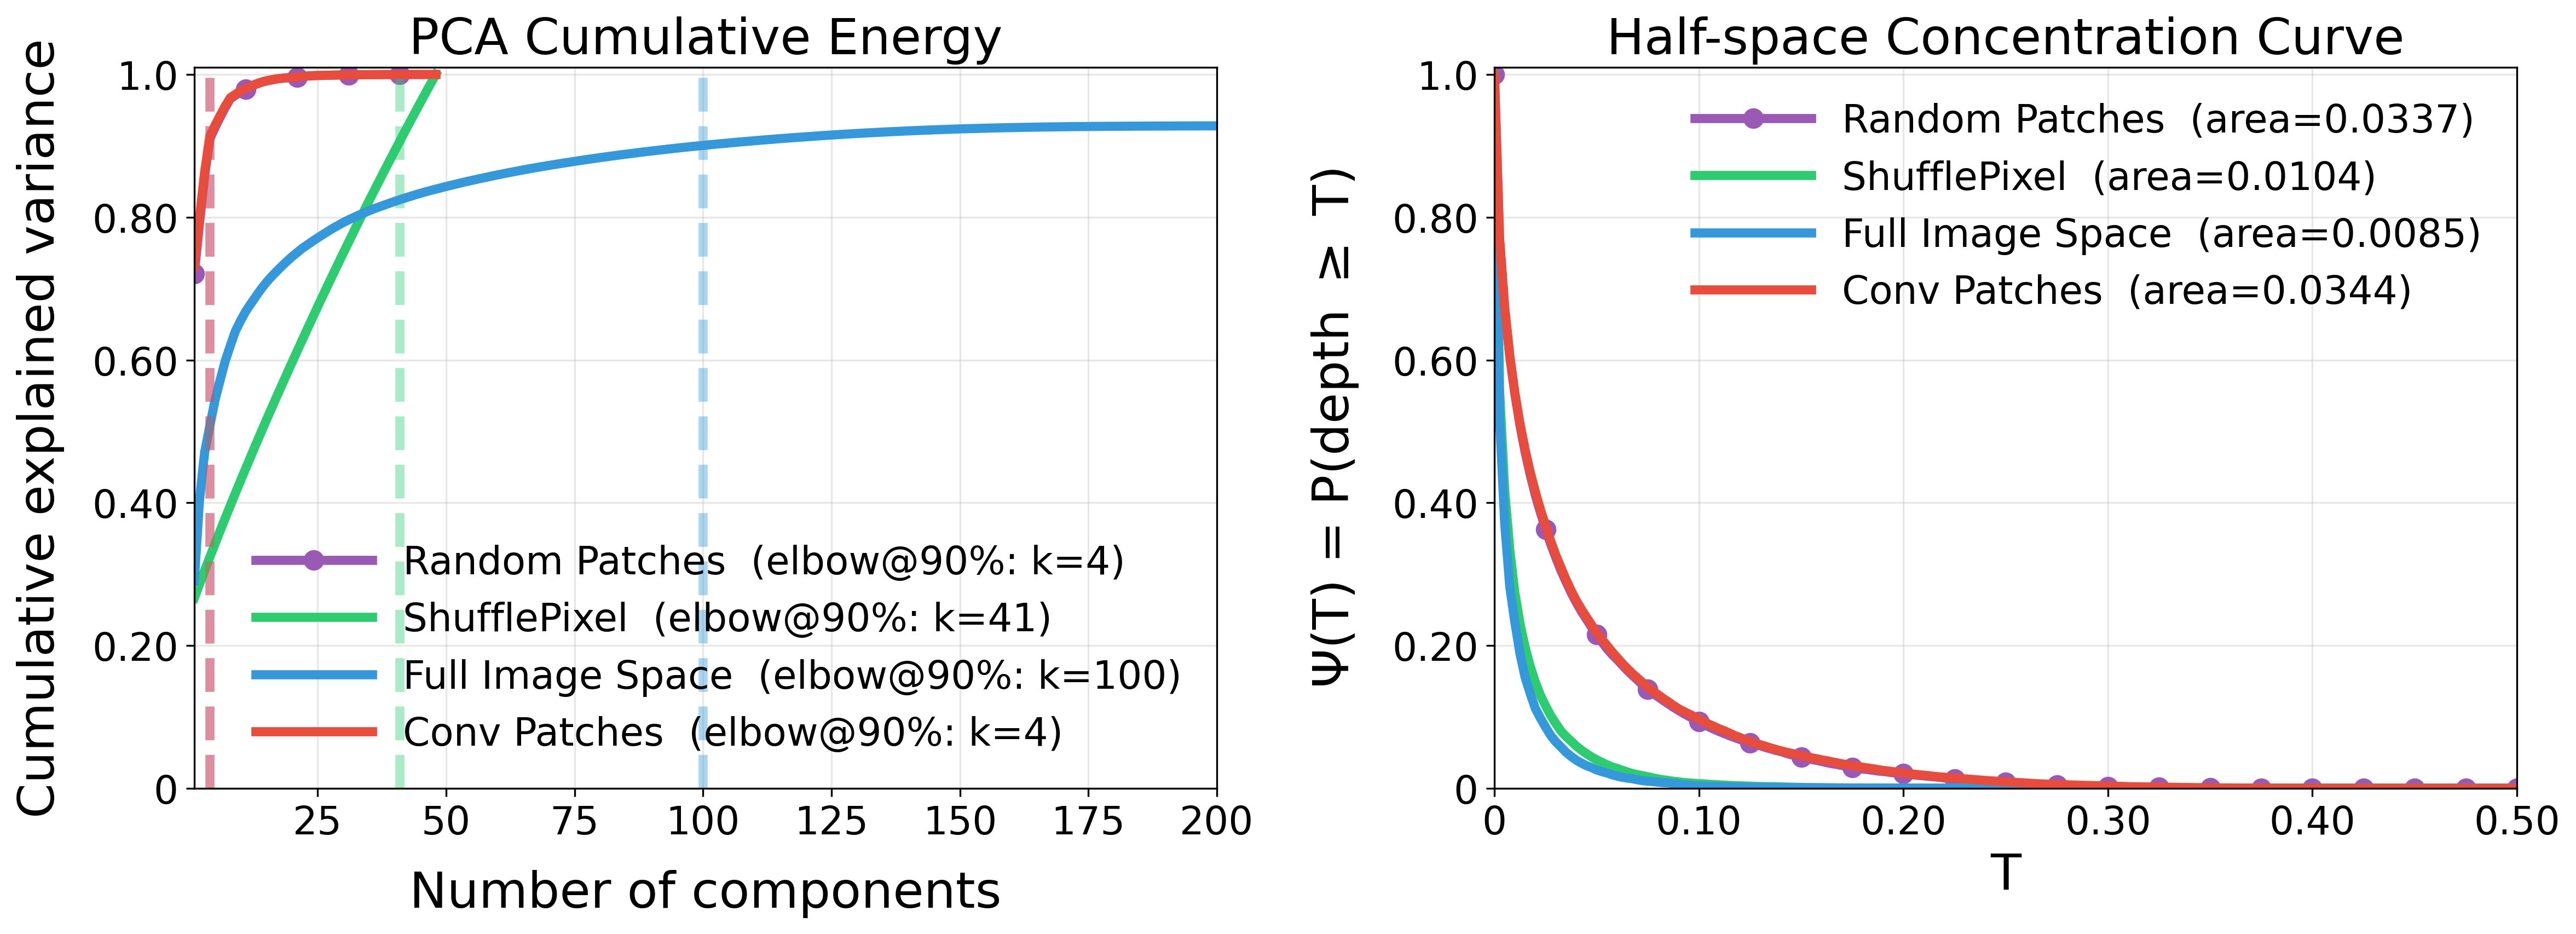

In [28]:
# =============================================================================
# Cell 10: 4-scheme comparison — Conv / Random Patches / ShufflePixel / Full Image Space
# =============================================================================

# ---------------------------------------------------------------------------
# Plot formatting — self-contained, no dependency on Cell 0 PLOT_CONFIG
# ---------------------------------------------------------------------------
TITLE_FS  = 22
LABEL_FS  = 22
TICK_FS   = 17
LEGEND_FS = 17
LW        = 4.0
FIG_SIZE  = (16, 6)
GRID_A    = 0.3

plt.rcParams.update({
    'font.size'       : TICK_FS,
    'axes.titlesize'  : TITLE_FS,
    'axes.labelsize'  : LABEL_FS,
    'xtick.labelsize' : TICK_FS,
    'ytick.labelsize' : TICK_FS,
    'legend.fontsize' : LEGEND_FS,
    'lines.linewidth' : LW,
})

# ---------------------------------------------------------------------------
# 1. Compute image-space baseline (3072-D)
# ---------------------------------------------------------------------------
IMG_NUM_DIRS = 512
IMG_NUM_BINS = 4096
IMG_QUERY_N  = 10_000

with torch.no_grad():
    img_mu  = X_all.mean(dim=0)
    q_idx   = torch.randperm(X_all.shape[0], device=DEVICE)[:IMG_QUERY_N]
    X_img_q = X_all[q_idx].contiguous()

@torch.no_grad()
def rpca_topk(X, k=200, oversample=32, niter=2):
    N, d = X.shape
    mu = X.mean(0); Xc = X - mu
    G  = torch.randn((d, k + oversample), device=X.device, dtype=X.dtype)
    Y  = Xc @ G
    for _ in range(niter): Y = Xc @ (Xc.T @ Y)
    Q, _ = torch.linalg.qr(Y, mode="reduced")
    _, S, _ = torch.linalg.svd(Q.T @ Xc, full_matrices=False)
    evals = (S[:k] ** 2) / (N - 1)
    trace = float((Xc.pow(2).sum(1).mean() * (N / (N - 1))).cpu())
    return evals, trace

img_evals, img_trace = rpca_topk(X_all)
IMG_CEV4   = np.cumsum(img_evals.cpu().numpy() / img_trace)
img_elbow4 = find_elbow(IMG_CEV4)

dirs_img  = sample_directions(IMG_NUM_DIRS, X_all.shape[1], DEVICE, seed=SEED + 5000)
img_depth = approx_tukey_depth(X_all, X_img_q, dirs_img, IMG_NUM_BINS, center=img_mu, eps=EPS)
if torch.cuda.is_available(): torch.cuda.synchronize()
img_depth_cpu = img_depth.detach().cpu().numpy()
IMG_PSI4  = np.array([(img_depth_cpu >= t).mean() for t in T_GRID], dtype=np.float64)
IMG_AREA4 = float(np.trapezoid(IMG_PSI4, T_GRID))
del img_depth, dirs_img, X_img_q
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f"Image space: elbow={img_elbow4}, area={IMG_AREA4:.6f}")

# ---------------------------------------------------------------------------
# 2. Series
# ---------------------------------------------------------------------------
FOUR_COLORS = {
    "Conv"            : "#E74C3C",   # red — matches clean_patch_vs_image_depth
    "RandomPlacement" : "#9B59B6",   # purple
    "GlobalShuffle"   : "#2ECC71",   # green — matches "Random Patch" in clean_patch_vs_image_depth
    "ImageSpace"      : "#3498DB",   # blue — matches "Image Space" in clean_patch_vs_image_depth
}
FOUR_LS = {}  # all main lines solid; dashes only on axvline markers
FOUR_MARKER = {
    "RandomPlacement" : "o",   # circles
}
MARKER_EVERY = 10  # place a marker every N data points

series4 = [
    ("RandomPlacement", RESULTS["RandomPlacement"]["CEV"], T_GRID, RESULTS["RandomPlacement"]["PSI"],  RESULTS["RandomPlacement"]["area"],  RESULTS["RandomPlacement"]["elbow"],  "Random Patches"),
    ("GlobalShuffle",   RESULTS["GlobalShuffle"]["CEV"],   T_GRID, RESULTS["GlobalShuffle"]["PSI"],    RESULTS["GlobalShuffle"]["area"],    RESULTS["GlobalShuffle"]["elbow"],    "ShufflePixel"),
    ("ImageSpace",      IMG_CEV4,                          T_GRID, IMG_PSI4,                           IMG_AREA4,                           img_elbow4,                           "Full Image Space"),
    ("Conv",            RESULTS["Conv"]["CEV"],            T_GRID, RESULTS["Conv"]["PSI"],            RESULTS["Conv"]["area"],            RESULTS["Conv"]["elbow"],            "Conv Patches"),
]

# ---------------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

ax = axes[0]
for key, cev, _, __, ___, elbow, label in series4:
    _marker = FOUR_MARKER.get(key, None)
    _mevery = MARKER_EVERY if _marker else None
    ax.plot(np.arange(1, len(cev) + 1), cev,
            color=FOUR_COLORS[key], linestyle=FOUR_LS.get(key, "-"),
            marker=_marker, markevery=_mevery, markersize=8,
            label=f"{label}  (elbow@90%: k={elbow})")
    ax.axvline(elbow, color=FOUR_COLORS[key], linestyle="--", alpha=0.4)
ax.set_title("PCA Cumulative Energy")
ax.set_xlabel("Number of components", labelpad=12)
ax.set_ylabel("Cumulative explained variance", labelpad=12)
ax.set_ylim(0.0, 1.01)
ax.set_xlim(1, max(len(s[1]) for s in series4))
ax.grid(True, alpha=GRID_A)
ax.yaxis.set_major_formatter(fmt)
ax.legend(frameon=False, handlelength=3)

ax = axes[1]
for key, _, t_grid, psi, area, __, label in series4:
    _marker = FOUR_MARKER.get(key, None)
    _mevery = MARKER_EVERY if _marker else None
    ax.plot(t_grid, psi,
            color=FOUR_COLORS[key], linestyle=FOUR_LS.get(key, "-"),
            marker=_marker, markevery=_mevery, markersize=8,
            label=f"{label}  (area={area:.4f})")
ax.set_title("Half-space Concentration Curve")
ax.set_xlabel("T")
ax.set_ylabel(r"$\Psi$(T) = P(depth $\geq$ T)", labelpad=14)
ax.set_ylim(0.0, 1.01)
ax.set_xlim(0.0, 0.5)
ax.grid(True, alpha=GRID_A)
ax.xaxis.set_major_formatter(fmt)
ax.yaxis.set_major_formatter(fmt)
ax.legend(frameon=False, handlelength=3)

fig.tight_layout()
os.makedirs("./figures", exist_ok=True)
fig.savefig("./figures/four_scheme_geometry.pdf", format="pdf", bbox_inches="tight")
print("Saved: figures/four_scheme_geometry.pdf")
plt.show()